# Basics on Image Processing and Manipulation

### The purpose of this practice is to get familiar with the basics of skimage and learn to solve simple image processing operations. 

The main topics are:
1. Image reading, saving and creation
2. Data types
3. Image manipulation 

**Requirements:** The code should be:
- working and optimized (e.g. do not use 'for' instruction when indexing numpy arrays)
- readable  (e.g. avoiding the implementation of more than 2 loops within a line)
- well commented in English.

### Packages loading 

First, we need to import the required Python packages for basic image manipulation. 

Run the following code:

In [1]:
import numpy as np # useful for manipulating matrices
from skimage import io # useful for image loading and saving
from matplotlib import pyplot as plt # useful for plotting images on iPython or Jupyter Notebooks

Note that commands starting with the percentage sign (`%`) are special internal commands to ipython (as opposed to Python code to be run). In the case below, we set the matplotlib environment to display images results inline (i.e. the images will be shown **inside the 
notebook**):

In [2]:
%matplotlib inline

## --------------------------------------------------------------------------------------


### 1.1 Image creation, saving and loading

Remember that [Numpy](https://docs.scipy.org/doc/numpy-1.13.0/reference/) allows us to define images of different kinds treating them as matrices.

The most common examples are:

* Binary: with values of 0 or 1, interpreted as black or white, respectively.
* Grayscale: with possible data types uint8, uint16, double, whose pixel values define their intensity.
* RGB Image: color images consisting of 3 matrices (usually called 'channels'), which contain intensity values for each color separately R (red), G (green) and B (blue).


a) Create and display a grayscale image that has 150 rows and 200 columns where each value should be of type unsigned integer with 8 bits. Check its dimensions and type.

**Your Solution:** 

(150, 200)


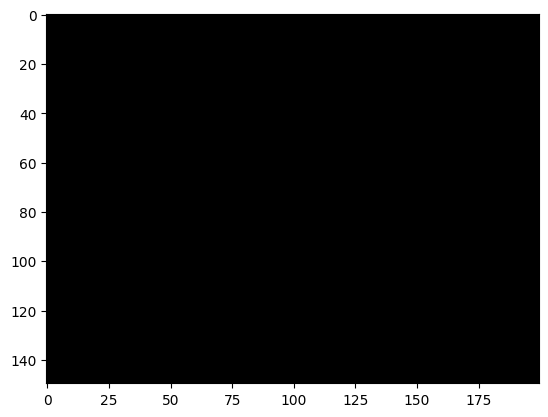

In [3]:
"""Solution"""
im = np.zeros((150,200), dtype='uint8')
print(im.shape)
plt.imshow(im, cmap='gray')
plt.show()

- How many different values can each pixel have in this case? 

**Your answer:** 



b) Change the color of the pixels of the image in such a way that the left half is black (0) and the right half is white (255). Visualize the image and print the values of its first row. Do not use explicit numbers for the indices, but deduce them from the dimensions of the image.

<img src="images/black_and_white.jpg">

**Your Solution:** 

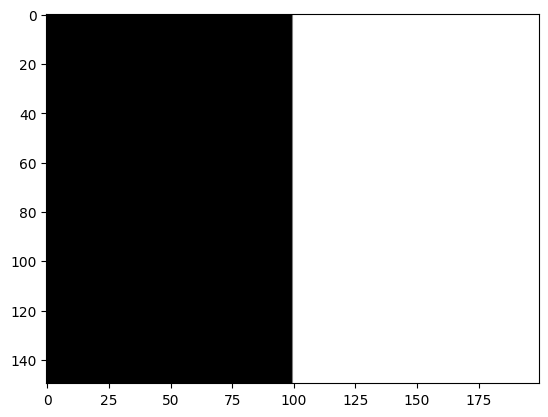

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255]


In [4]:
"""Solution"""
im[:, 100:] = 255

plt.imshow(im, cmap='gray')
plt.show()

print(im[0])

c) Use the IO image package to save the image previously created:

**Your Solution:** 

In [5]:
"""Solution"""
io.imsave('black_and_white.jpg', im)

b) Load the saved image and visualize it:

**Your Solution:** 

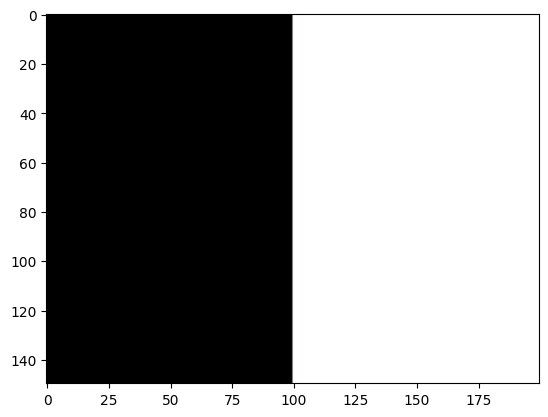

In [6]:
"""Solution"""
im2 = io.imread('black_and_white.jpg')
plt.imshow(im2, cmap='gray')
plt.show()

## ----------------------------------------------------------------------------------------------------------


### 1.2 Color image manipulation

a) Load and show the image `lenna.jpg`. Check its dimensions.

**Note:** Pictures may appear in the figure with pseudocolors. Use (imread,im,cmap='rgb') to display them in RGB color and (imread,im,cmap='gray') to display them in grayscale. For more information, check the color maps available in the documentation.

**Your Solution:** 

(225, 400, 3)
(225, 400)
float64
0.9869937254901961


c:\Users\klkle\anaconda3\Lib\site-packages\skimage\_shared\utils.py:328: UserWarning: lenna_black_and_white.jpg is a low contrast image
  return func(*args, **kwargs)


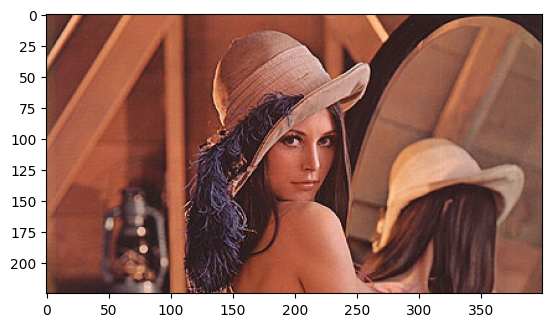

In [7]:
"""Solution"""
im = io.imread('images/lenna.jpg')
plt.imshow(im)
print(im.shape)


"""Solution"""
# Show both images (RGB & grayscale) details such as shape, dtype, max and min values.
from skimage.color import rgb2gray
im_gray = rgb2gray(im)
print(im_gray.shape)
print(im_gray.dtype)
print(im_gray.max())

# Save new grayscale image
io.imsave('lenna_black_and_white.jpg', im_gray.astype('uint8'))

b) Convert the previous image to grayscale, and visualize and save it. Note that there are 2 different solutions for the conversion. Check the maximum and minimum values of lena and lena grayscale.

**Your Solution:** 

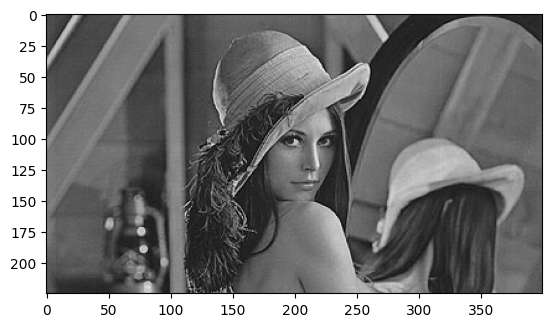

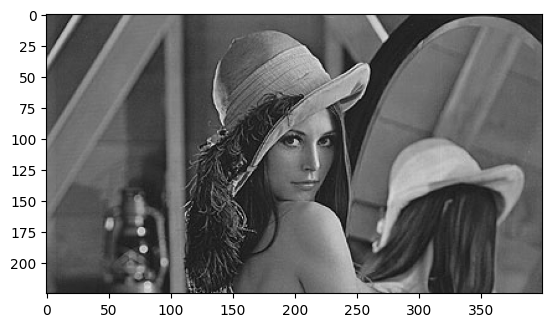

In [8]:
"""Solution"""

# Convert & Visualize 

#1)
im_gray = im.mean(axis=2)
plt.imshow(im_gray, cmap='gray') # we must use the parameter cmap='gray' when plotting grayscale images
plt.show()

#2) Following tutorial
img_gray = rgb2gray(im)
plt.imshow(img_gray, cmap='gray')
plt.show()

c) Convert the lena image into a boolean image, by applying a binarization to the grayscale image. A binarization of an image is the process of setting to 0 all values equal or below 100 and to 1 otherwise. Check the range of the values of the image, and print the 10th row. This should be done by setting to 0 all values equal or below 100 and to 1 otherwise. Check the range of the values of the image, and print the 10th row. Check the maximum and minimum values of lena binarizada.

**Your Solution:** 

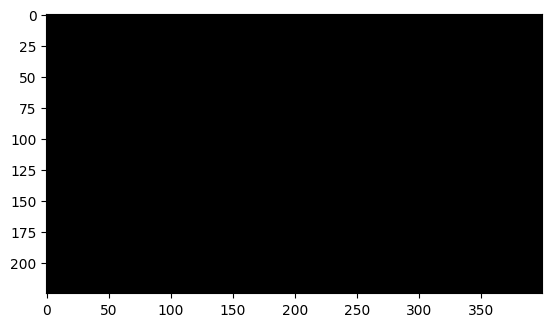

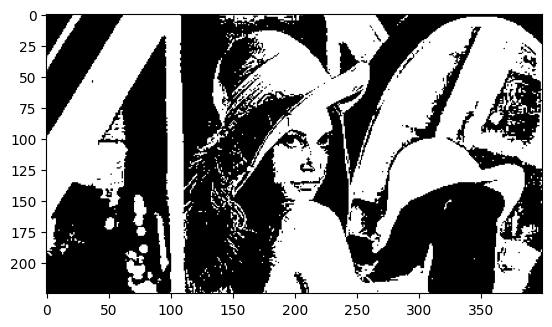

In [9]:
"""Solution"""
thresholded_im_bool = (im_gray > 100/255.0)
thresholded_im = np.zeros((im.shape[0], im.shape[1]), dtype='uint8')

thresholded_im[thresholded_im_bool]=1

plt.imshow(thresholded_im, cmap='gray')
plt.show()

# Following the tutorial
thresholded_im_bool_tutorial = im_gray
thresholded_im_bool_tutorial [thresholded_im_bool_tutorial>100] = 1
thresholded_im_bool_tutorial [thresholded_im_bool_tutorial!=1] = 0
plt.imshow(thresholded_im_bool_tutorial,cmap='gray')
plt.show()

In [10]:
"""Solution"""
print(np.min(im))
print(np.max(im))

print(im_gray[10,:])

0
255
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.

d) Visualize in the same figure three images: (1) the original image, (2) the graylevel image, and (3) the binarized image. Set the corresponding titles of the images.

**Your Solution:** 

C:\Users\klkle\AppData\Local\Temp\ipykernel_31448\1961069810.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


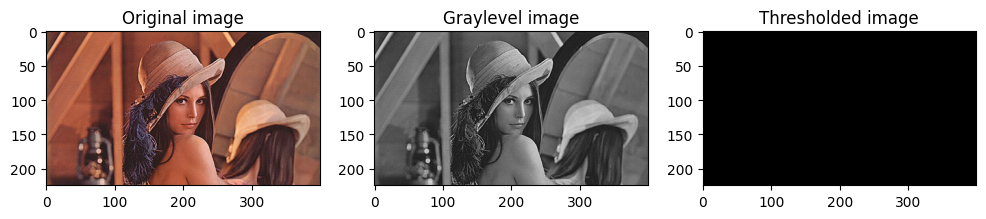

In [11]:
"""Solution"""
from skimage import color

im_gray = color.rgb2gray(im) # convert to grayscale representation

fig, (ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(12,30))

ax1.imshow(im, )
ax1.set_title('Original image')
ax2.imshow(im_gray, cmap='gray')
ax2.set_title('Graylevel image')
ax3.imshow(thresholded_im, cmap='gray')
ax3.set_title('Thresholded image')
fig.show()

## ----------------------------------------------------------------------------------------------------------


### 1.3 Images manipulation

a) Add a black frame to Lenna's image. It should have a width of 1/10th of the height of the original image without occluding part of the image. 

<img src="images_notebook/lena_frame.png">

**Your Solution:** 

22
(225, 400, 3)


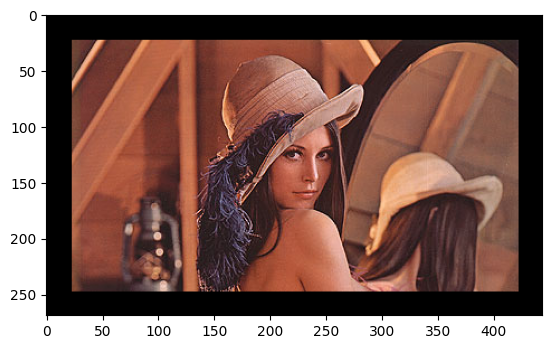

In [13]:
"""Solution"""
'''
plt.imshow(im)
fig.show()'''
im = io.imread('images/lenna.jpg')
mask=int(im.shape[0]/10)
print(mask)
print(im.shape)

"""Solution"""
big_im = np.zeros((int(im.shape[0]+2*mask), int(im.shape[1]+2*mask), 3), dtype='uint8')
big_im[mask+1:im.shape[0]+mask+1, mask+1:im.shape[1]+mask+1] = im

plt.imshow(big_im)
plt.show()

b) 
- Change the mask of the framed image to red. 
- Visualize the three images with their respective titles.

**Your Solution:** 

Solution to : Change mask of the framed image to red


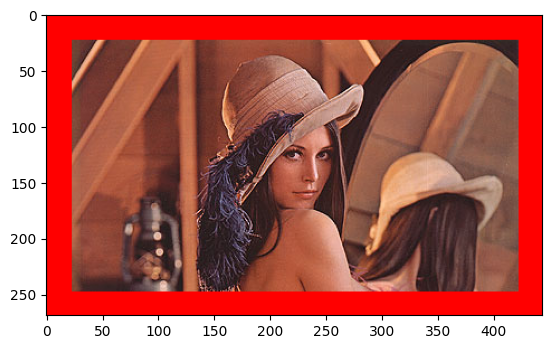

Solution to : Visualize the three images
(225, 400, 3)


C:\Users\klkle\AppData\Local\Temp\ipykernel_31448\3628391809.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


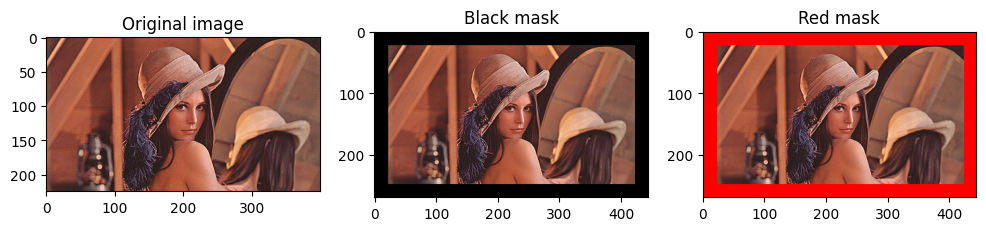

In [14]:
"""Solution"""
print('Solution to : Change mask of the framed image to red')
big_red_im = big_im.copy()
big_red_im[:,1:mask+1] = (255,0,0)
big_red_im[:,im.shape[1]+mask+1:im.shape[1]+2*mask+1] = (255,0,0)

big_red_im[1:mask+1,:] = (255,0,0)
big_red_im[im.shape[0]+mask+1:im.shape[0]+2*mask+1,:] = (255,0,0)

plt.imshow(big_red_im)
plt.show()



"""Solution"""
print('Solution to : Visualize the three images')
fig, (ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(12,30))
print (im.shape)

ax1.imshow(im, )
ax1.set_title('Original image')
ax2.imshow(big_im, cmap='gray')
ax2.set_title('Black mask')
ax3.imshow(big_red_im, cmap='gray')
ax3.set_title('Red mask')
fig.show()

## ----------------------------------------------------------------------------------------------------------

### 1.4 Masks and logical image manipulation

- Import/read the image `circles.bmp` (see figure top) 

- Define 3 images in such a way that each one contains only 1 ball (see figure bottom). Balls should be extracted by defining their grey value range.

- Visualize the 3 images in the same figure (e.g. plt.subplots(ncols=3, figsize=(10,20))). Add titles to the figures

<img src="images/ex16.png">

**Note:** Be careful when applying `imshow` since it automatically increases the contrast of the image (putting minimum values to 0 and maximal to 1).

**Note:** Be careful when applying type conversion. Check the ranges of the image values.

**Your Solution:** 

float64


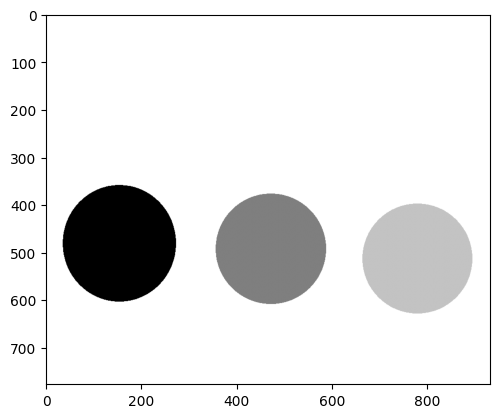

In [15]:
"""Solution"""
from skimage import color

imrgb = io.imread('images/circles.bmp')
im = color.rgb2gray(imrgb)
print(im.dtype)

plt.imshow(im, cmap='gray')
plt.show()

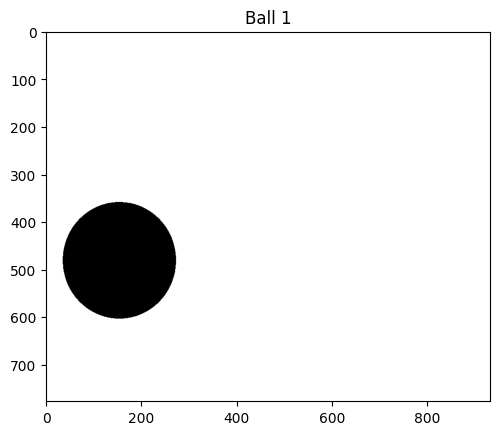

In [16]:
"""Solution"""
im_left = im.copy()
im_left = (im<0.1)

im_left = 1-im_left

plt.imshow(im_left, cmap='gray', vmin=0, vmax=1)
plt.title('Ball 1')
plt.show()

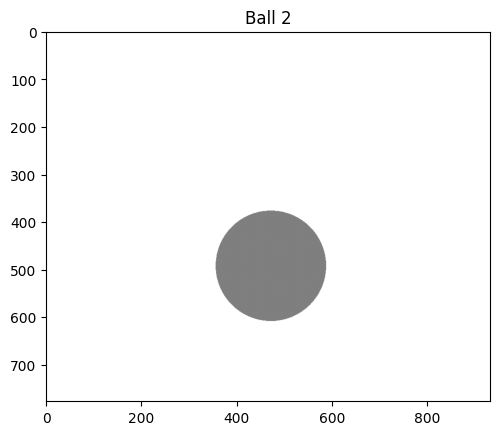

In [17]:
"""Solution"""
from skimage import img_as_uint

im_middle_bool = im.copy()
im_middle_bool = (im==127/255.0)

im_middle = np.multiply(im,im_middle_bool)
im_middle[(im_middle==0)] = 1

plt.imshow(im_middle, cmap='gray', vmin=0, vmax=1)
plt.title('Ball 2')
plt.show()

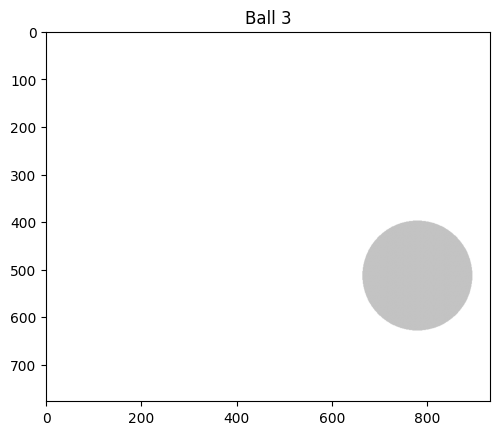

In [18]:
"""Solution"""
im_right = im.copy()
im_right = (im==195/255.0)

im_right = np.multiply(im, im_right)
im_right[(im_right==0)] = 1

plt.imshow(im_right, cmap='gray', vmin=0, vmax=1)
plt.title('Ball 3')
plt.show()

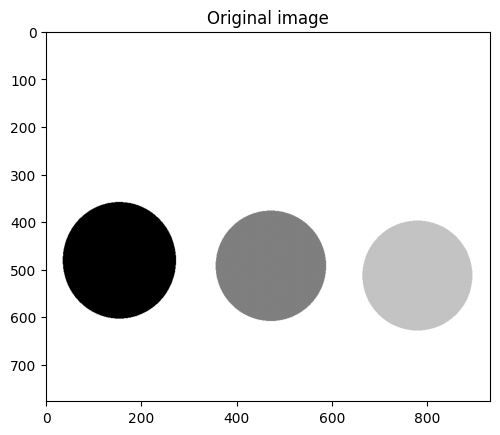

C:\Users\klkle\AppData\Local\Temp\ipykernel_31448\1863499971.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


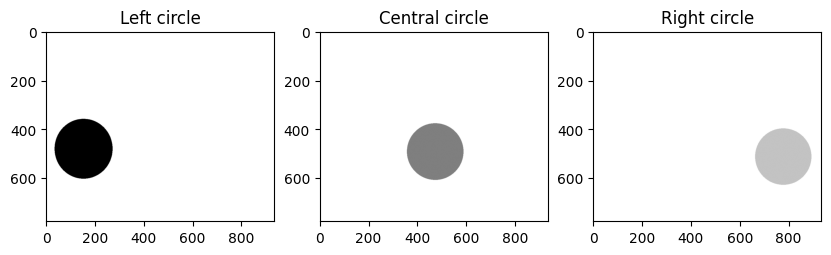

In [19]:
"""Solution"""
plt.imshow(im, cmap='gray')
plt.title('Original image')
plt.show()

fig, (ax1,ax2,ax3)=plt.subplots(ncols=3, figsize=(10,20))

ax1.imshow(im_left, cmap='gray', vmin=0, vmax=1)
ax1.set_title('Left circle')

ax2.imshow(im_middle, cmap='gray', vmin=0, vmax=1)
ax2.set_title('Central circle')

ax3.imshow(im_right, cmap='gray', vmin=0, vmax=1)
ax3.set_title('Right circle')
fig.show()

## ----------------------------------------------------------------------------------------------------------


### 1.5 Color manipulation

a)  Create and visualize the three images shown in the following figure:
<img src="./images/ex17a.png">

- Using these three images, construct the following color image:
<img src='./images/ex17b.png'>

**Your Solution:** 

C:\Users\klkle\AppData\Local\Temp\ipykernel_31448\3165411101.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


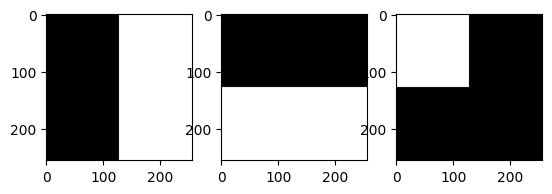

In [20]:
"""Solution"""
im_r = np.zeros((256,256))
im_g = np.zeros((256,256))
im_b = np.zeros((256,256))

im_r[:,128:]=1
im_g[128:,:]=1
im_b[:128,:128]=1

fig,(ax1,ax2,ax3)=plt.subplots(ncols=3)

ax1.imshow(im_r, cmap='gray')
ax2.imshow(im_g, cmap='gray')
ax3.imshow(im_b, cmap='gray')
fig.show()

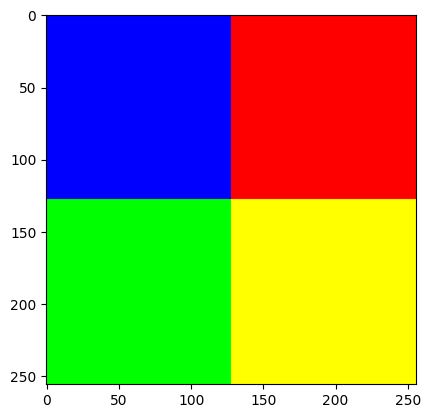

In [21]:
"""Solution"""
im_color=np.zeros((256,256,3))

im_color[:,:,0]=im_r
im_color[:,:,1]=im_g
im_color[:,:,2]=im_b

plt.imshow(im_color)
plt.show()

b) Read and visualize the image `chairs.jpg` (see figure top). 
- Extract its three channels and visualize them in the same figure with their respective titles (see the figure bottom).
<img src="images/chairsc.png">

<img src="images/chairsc2.png">



**Your Solution:** 

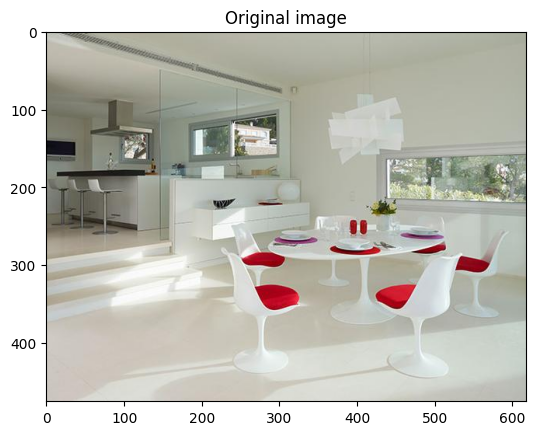

In [22]:
"""Solution"""
im=io.imread('images/chairs.jpg')

plt.imshow(im)
plt.title('Original image')
plt.show()

C:\Users\klkle\AppData\Local\Temp\ipykernel_31448\4041775769.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


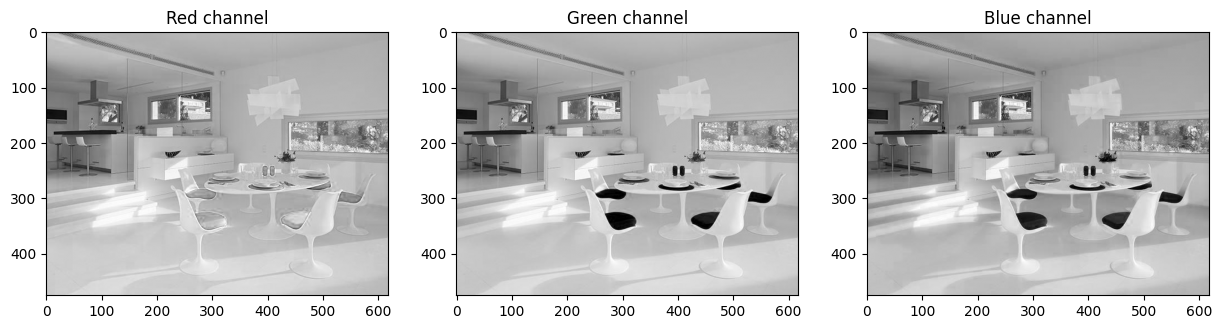

In [23]:
"""Solution"""
fig, (ax1,ax2,ax3)=plt.subplots(ncols=3, figsize=(15,30))
ax1.imshow(im[:,:,0], cmap='gray')
ax1.set_title('Red channel')
ax2.imshow(im[:,:,1], cmap='gray')
ax2.set_title('Green channel')
ax3.imshow(im[:,:,2], cmap='gray')
ax3.set_title('Blue channel')
fig.show()

- Construct and visualize a new image in which the red color of the chairs is changed to blue (see figure).
<img src="images/chairsc3.png">

**Your Solution:** 

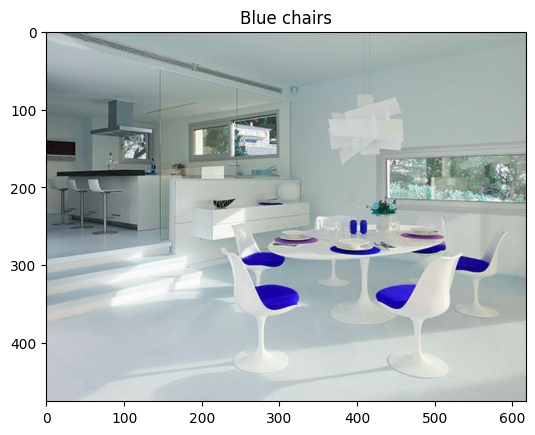

In [24]:
"""Solution"""
blue_chairs=np.zeros((im.shape), dtype='ubyte')
blue_chairs[:,:,2]=im[:,:,0]
blue_chairs[:,:,0]=im[:,:,2]
blue_chairs[:,:,1]=im[:,:,1]

plt.imshow(blue_chairs)
plt.title('Blue chairs')
plt.show()

c) Given the images `coat.png` and `model.png` (first two images on the figure below), implement the necessary code to construct the image of the model with the coat (third image). 

- Next find in internet an image with a texture and apply it to obtain an image of the jacket with the found texture (fourth image is an example).

<img src="images/ex17d.png">

**Note:** when applying resize, rotate, etc. keep track how the image type and values range change. When necessary, apply type conversion using img_as_float, img_as_uint, img_as_ubyte.

**Your Solution:** 

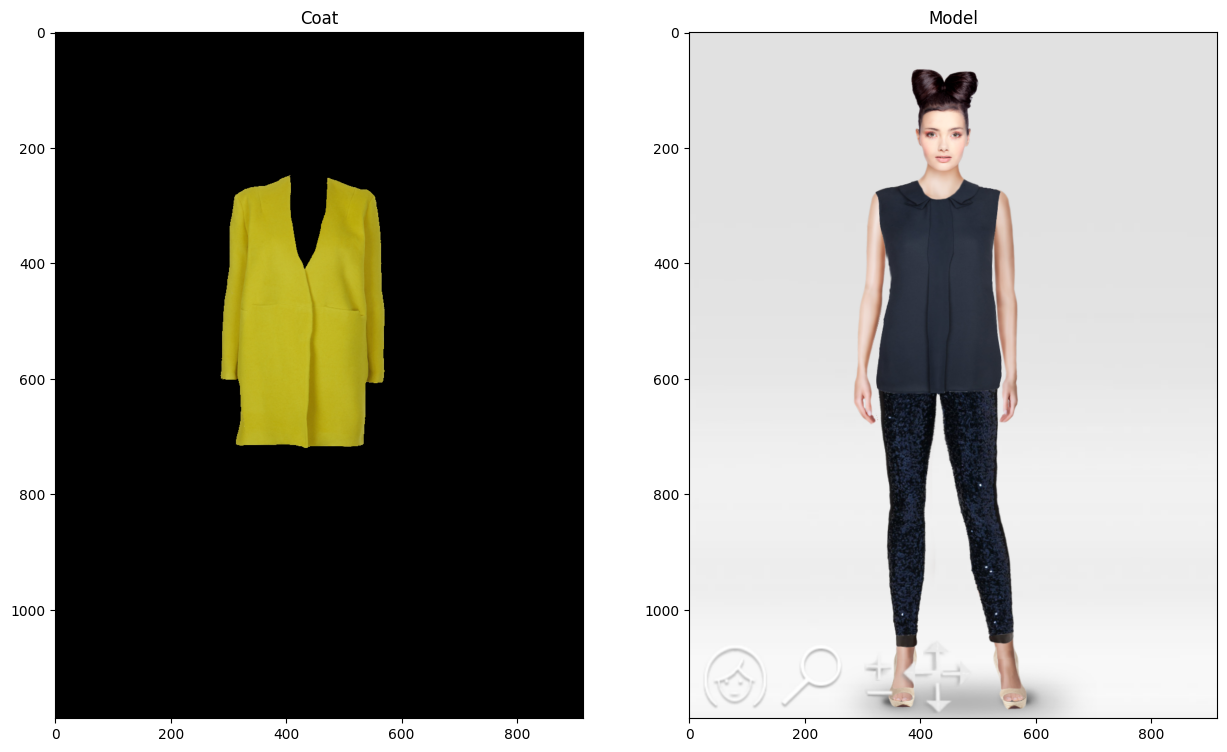

0 255 uint8 (1188, 915, 4)
0 255 uint8 (1188, 915, 4)
0.0 0.803921568627451 float64 (1188, 915, 3)
0.0 1.0 float64 (1188, 915, 3)


In [25]:
"""Solution"""
from skimage import color

im_coat=io.imread('images/coat.png')
im_model=io.imread('images/model.png')

fig, (ax1,ax2)=plt.subplots(ncols=2, figsize=(15,20))
ax1.imshow(im_coat, cmap='gray')
ax1.set_title('Coat')
ax2.imshow(im_model, cmap='rainbow')
ax2.set_title('Model')
plt.show()

print(im_coat.min(), im_coat.max(), im_coat.dtype, im_coat.shape)
print(im_model.min(), im_model.max(), im_model.dtype, im_model.shape)

im_coat2=color.rgba2rgb(im_coat)
im_model2=color.rgba2rgb(im_model)

print(im_coat2.min(), im_coat2.max(), im_coat2.dtype, im_coat2.shape)
print(im_model2.min(), im_model2.max(), im_model2.dtype, im_model2.shape)

C:\Users\klkle\AppData\Local\Temp\ipykernel_31448\3661310486.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


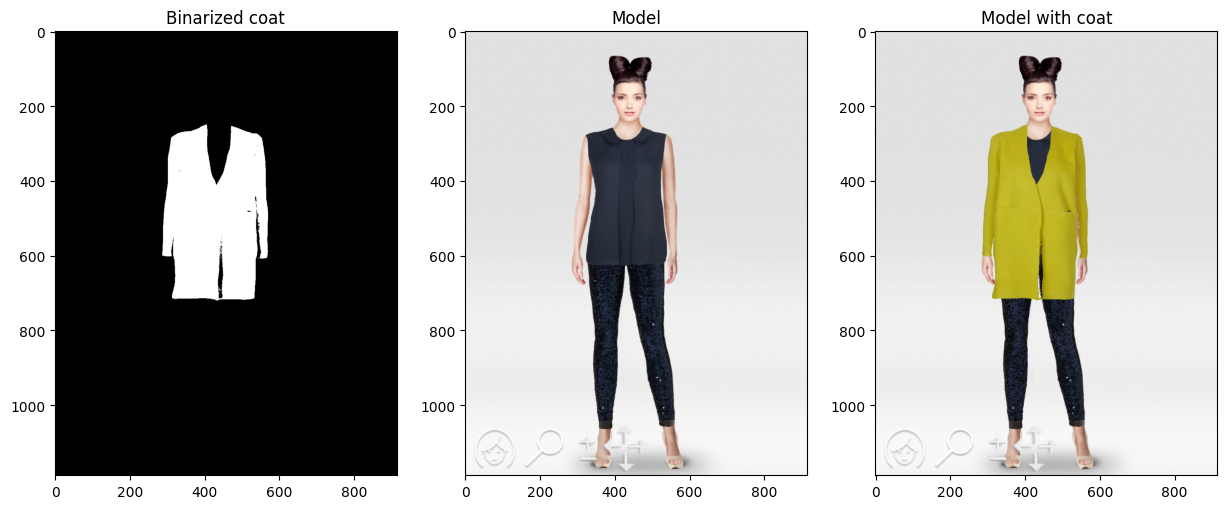

In [26]:
"""Solution"""
coat_bool = color.rgb2gray(im_coat2)
coat_bool = (coat_bool>0.5)

new_model = im_model2.copy()
new_model[(coat_bool)] = im_coat2[(coat_bool)]

fig, (ax1,ax2,ax3)=plt.subplots(ncols=3, figsize=(15,20))
ax1.imshow(coat_bool, cmap='gray')
ax1.set_title('Binarized coat')
ax2.imshow(im_model2, cmap='rainbow')
ax2.set_title('Model')
ax3.imshow(new_model, cmap='gray')
ax3.set_title('Model with coat')
fig.show()

0 255 uint8 (183, 275, 3)
0.0 1.0 float64 (275, 183, 3)
0.0 0.9999999999999963 float64 (1188, 915, 3)


C:\Users\klkle\AppData\Local\Temp\ipykernel_31448\198281652.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


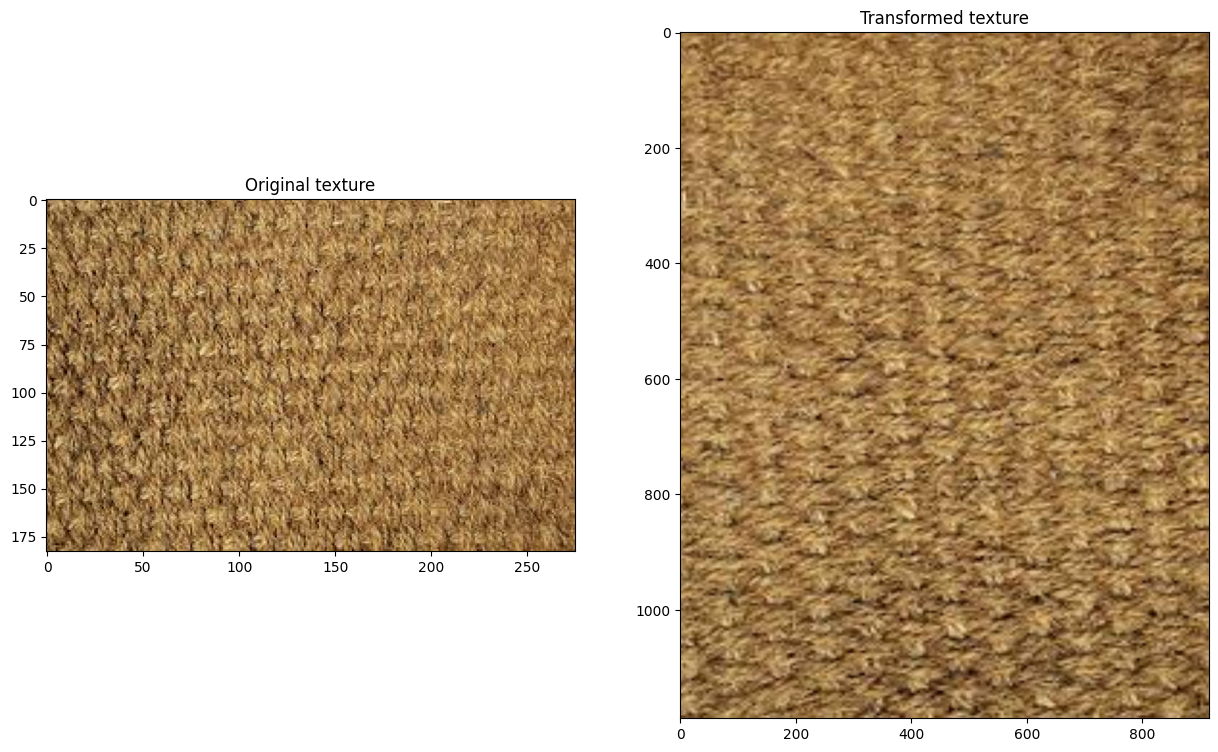

In [27]:
"""Solution"""
from skimage import transform

im_texture = io.imread('images/texture.png')
print(im_texture.min(), im_texture.max(), im_texture.dtype, im_texture.shape)

im_texture1 = transform.rotate(im_texture, 90, resize=True)
print(im_texture1.min(), im_texture1.max(), im_texture1.dtype, im_texture1.shape)

im_texture2 = transform.resize(im_texture1, (im_model2.shape))
print(im_texture2.min(), im_texture2.max(), im_texture2.dtype, im_texture2.shape)

fig, (ax1,ax2)=plt.subplots(ncols=2, figsize=(15,20))
ax1.imshow(im_texture, cmap='gray')
ax1.set_title('Original texture')
ax2.imshow(im_texture2, cmap='gray')
ax2.set_title('Transformed texture')
fig.show()

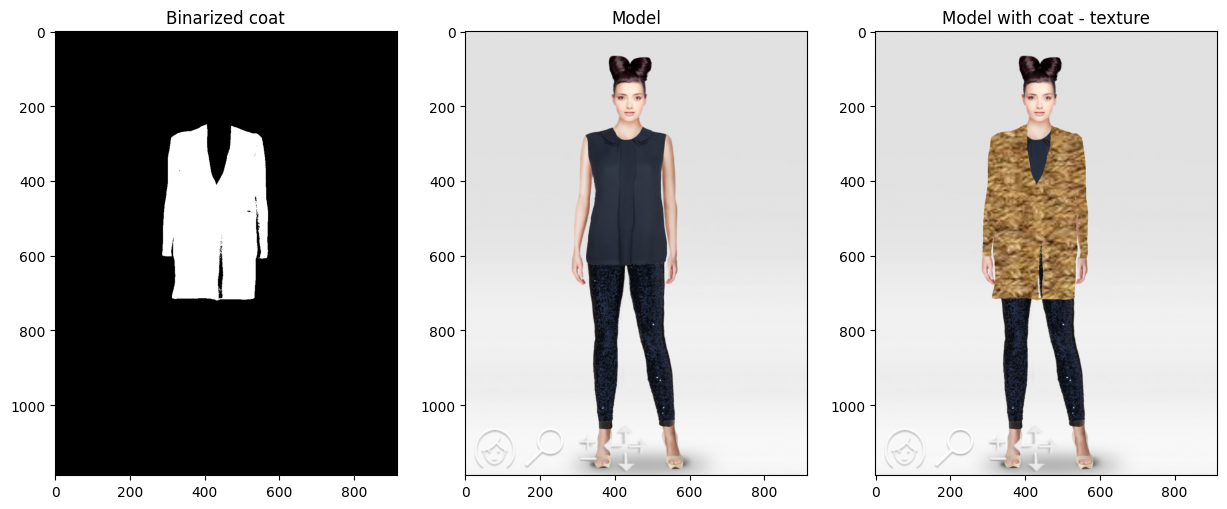

In [28]:
"""Solution"""
new_model2 = im_model2.copy()
new_model2[(coat_bool)] = im_texture2[(coat_bool)]

fig, (ax1,ax2,ax3)=plt.subplots(ncols=3, figsize=(15,20))
ax1.imshow(coat_bool, cmap='gray')
ax1.set_title('Binarized coat')
ax2.imshow(im_model2, cmap='rainbow')
ax2.set_title('Model')
ax3.imshow(new_model2, cmap='gray')
ax3.set_title('Model with coat - texture')
plt.show()